In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# Load your Kaggle datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.isnull().sum()


id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

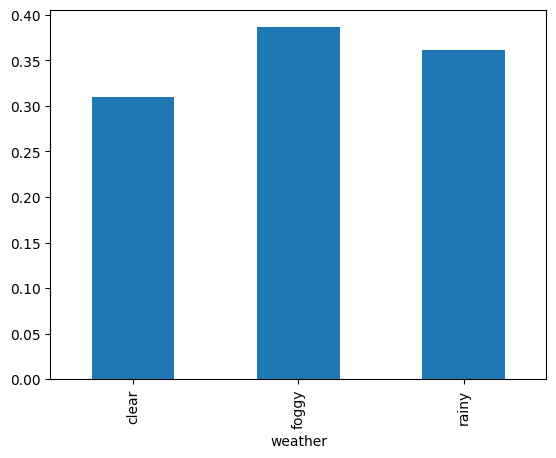

In [4]:
import matplotlib.pyplot as plt
train_df.groupby("weather")["accident_risk"].mean().plot(kind='bar')
plt.show()


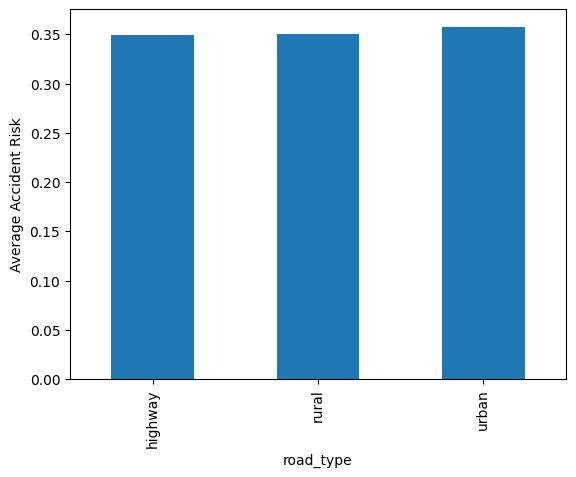

In [5]:
train_df.groupby("road_type")["accident_risk"].mean().plot(kind='bar')
plt.ylabel("Average Accident Risk")
plt.show()


In [6]:
train_df.groupby("road_signs_present")["accident_risk"].mean()
train_df.groupby("public_road")["accident_risk"].mean()
train_df.groupby("holiday")["accident_risk"].mean()
train_df.groupby("school_season")["accident_risk"].mean()


school_season
False    0.352539
True     0.352214
Name: accident_risk, dtype: float64

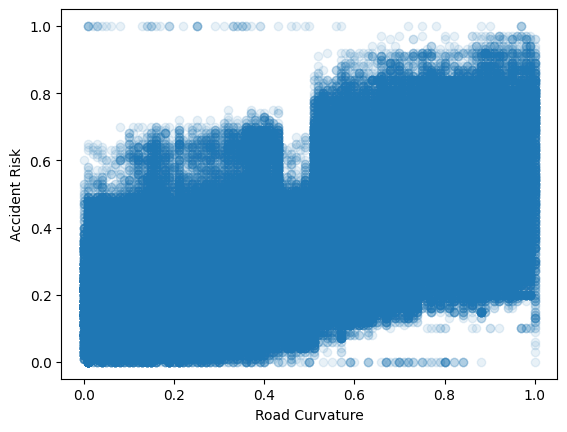

In [7]:
plt.scatter(train_df['curvature'], train_df['accident_risk'], alpha=0.1)
plt.xlabel("Road Curvature")
plt.ylabel("Accident Risk")
plt.show()


In [ ]:

le = LabelEncoder()
for col in train_df.select_dtypes(include=['object']).columns:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

In [ ]:

X = train_df.drop(['id', 'accident_risk'], axis=1)
y = (train_df['accident_risk'] > 0.5).astype(int)

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data for the Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)


In [13]:
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)


In [14]:
print(f"Random Forest Accuracy: {accuracy_score(y_val, rf_preds) * 100:.2f}%")

Random Forest Accuracy: 93.89%


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display basic statistics
print(train_df.describe())

# Check for missing values (Essential for Data Cleaning)
print(train_df.isnull().sum())

                  id      road_type      num_lanes      curvature  \
count  517754.000000  517754.000000  517754.000000  517754.000000   
mean   258876.500000       0.995540       2.491511       0.488719   
std    149462.849975       0.816326       1.120434       0.272563   
min         0.000000       0.000000       1.000000       0.000000   
25%    129438.250000       0.000000       1.000000       0.260000   
50%    258876.500000       1.000000       2.000000       0.510000   
75%    388314.750000       2.000000       3.000000       0.710000   
max    517753.000000       2.000000       4.000000       1.000000   

         speed_limit       lighting        weather    time_of_day  \
count  517754.000000  517754.000000  517754.000000  517754.000000   
mean       46.112575       0.957312       0.956889       1.003675   
std        15.788521       0.801956       0.804774       0.816191   
min        25.000000       0.000000       0.000000       0.000000   
25%        35.000000       0.0000

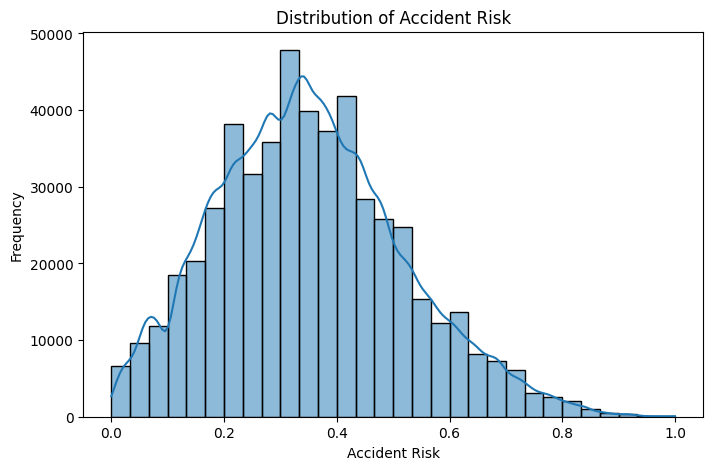

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(train_df['accident_risk'], bins=30, kde=True)
plt.title("Distribution of Accident Risk")
plt.xlabel("Accident Risk")
plt.ylabel("Frequency")
plt.show()



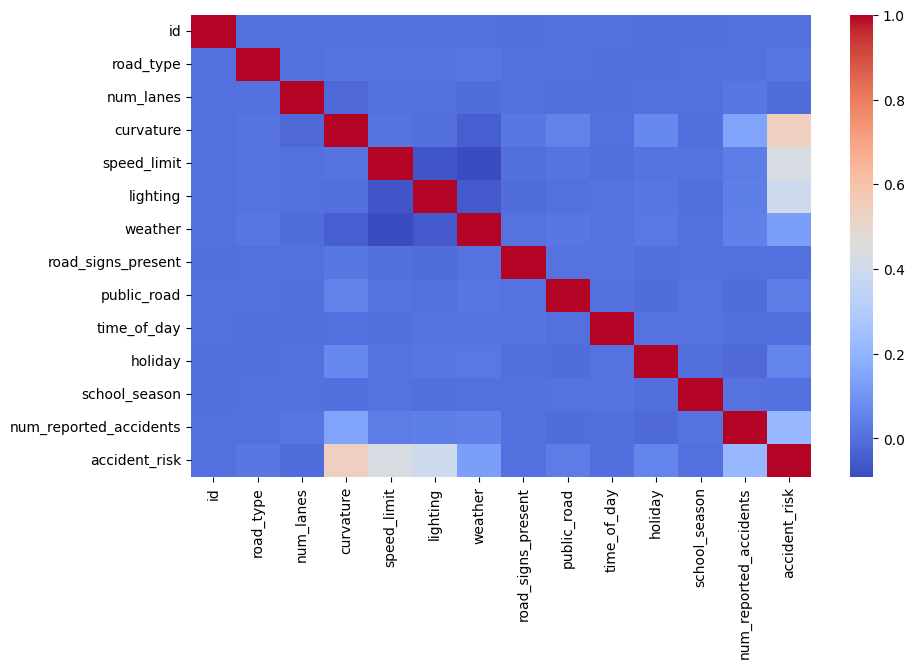

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(train_df.corr(), annot=False, cmap='coolwarm')
plt.show()



C:\Users\jayam\AppData\Local\Temp\ipykernel_16696\3992411162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


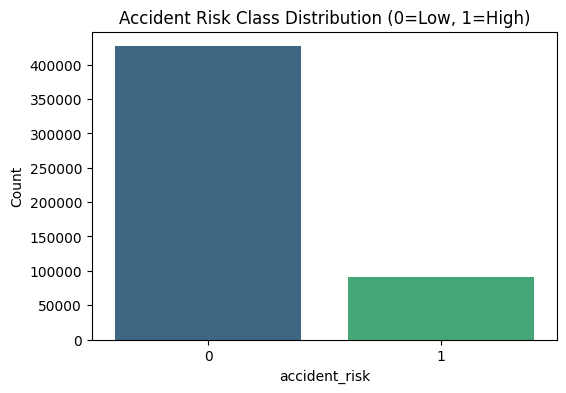

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Accident Risk Class Distribution (0=Low, 1=High)')
plt.ylabel('Count')
plt.show()

In [20]:
# 1. Prepare the actual Test features (remove the 'id' column)
# Make sure the columns in X_test match the columns in X_train exactly
X_test = test_df.drop(['id'], axis=1)

# 2. Predict using the full Test set (NOT X_val)
test_predictions = rf_model.predict(X_test)

# 3. Now the lengths will match perfectly (172,585 rows each)
submission = pd.DataFrame({
    'id': test_df['id'],
    'accident_risk': test_predictions
})

# 4. Save for Kaggle submission
submission.to_csv('submission2.csv', index=False)
print("Success! Submission file created with matching lengths.")

Success! Submission file created with matching lengths.


In [26]:
import joblib

joblib.dump(rf_model, "accident_risk_model.pkl")


['accident_risk_model.pkl']

In [27]:
import joblib
joblib.dump(X.columns, "model_columns.pkl")


['model_columns.pkl']

In [1]:
import joblib

cols = joblib.load("model_columns.pkl")
print(len(cols))
print(cols)

12
Index(['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents'],
      dtype='object')


In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = rf_model.predict(X_val)


In [22]:
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")



Test Accuracy: 0.9389
F1 Score: 0.8092


In [23]:
labels = ['Low Risk', 'High Risk']

report = classification_report(y_val, y_pred, target_names=labels)
print("\nClassification Report:\n", report)



Classification Report:
               precision    recall  f1-score   support

    Low Risk       0.95      0.98      0.96     85508
   High Risk       0.89      0.74      0.81     18043

    accuracy                           0.94    103551
   macro avg       0.92      0.86      0.89    103551
weighted avg       0.94      0.94      0.94    103551



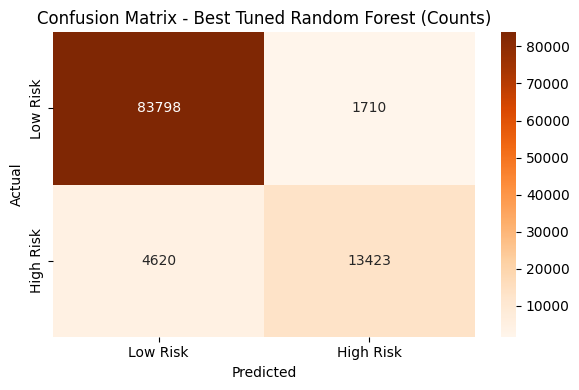

In [24]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Best Tuned Random Forest (Counts)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


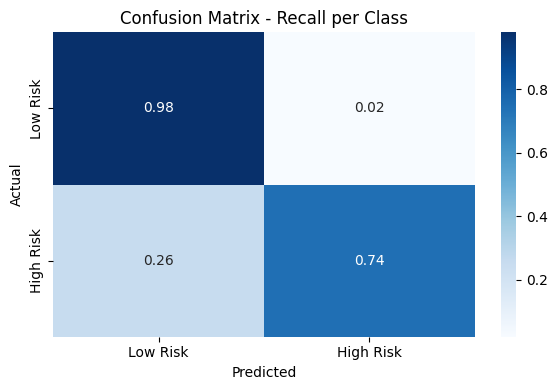

In [25]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,4))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Recall per Class')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
